In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

## 1. SGD Ridge Function


## 1. SGD Ridge Function

The Ridge objective function is:

$$f(\mathbf{b}) = \frac{1}{n} \sum_{i=1}^{n} \left[ (Y_i - b_0 - b_1 X_{i1} - \dots - b_p X_{ip})^2 + \lambda \sum_{j=1}^{p} b_j^2 \right]$$

This has the form $f(\mathbf{b}) = \frac{1}{n} \sum_{i=1}^n g_i(\mathbf{b})$, where:

$$g_i(\mathbf{b}) = (Y_i - \mathbf{X}_i' \mathbf{b})^2 + \lambda \sum_{j=1}^{p} b_j^2$$

The gradient of $g_i$ with respect to $\mathbf{b}$ is:

$$\nabla g_i(\mathbf{b}) = -2(Y_i - \mathbf{X}_i' \mathbf{b}) \mathbf{X}_i + 2\lambda (0, b_1, \dots, b_p)'$$

Note: we do **not** penalize the intercept $b_0$.

### SGD Algorithm:
0. Specify $\gamma_m > 0$ and starting point $\mathbf{b}$
1. For $m = 1, 2, \dots$ repeat:
   - Sample random index $i$ from $\{1, \dots, n\}$
   - Compute $\nabla g_i(\mathbf{b})$
   - Update $\mathbf{b} \leftarrow \mathbf{b} - \gamma_m \nabla g_i(\mathbf{b})$

In [2]:
def sgd_ridge(X, y, lam=1.0, x0=None, max_iter=10000, lr=0.01, lr_schedule='sqrt_decay'):
    """
    Compute the Ridge estimator via Stochastic Gradient Descent.

    Parameters
    ----------
    X          : numpy array of shape (n, p+1), design matrix with column of 1s for intercept
    y          : numpy array of shape (n,), response vector
    lam        : float, regularization parameter lambda
    x0         : numpy array of shape (p+1,), starting value (default: zeros)
    max_iter   : int, maximum number of iterations
    lr         : float, base learning rate
    lr_schedule: str, one of 'constant', 'decay', 'sqrt_decay'

    Returns
    -------
    b       : numpy array, the estimated coefficients (b_0, b_1, ..., b_p)
    history : list of floats, objective function values recorded every 100 steps
    """
    n, d = X.shape  # reads dimensions of matrix X

    # Initialize coefficients (ridge) start at 0, unless otherwide provided
    if x0 is not None:
        b = np.array(x0, dtype=float)
    else:
        b = np.zeros(d)

    # Penalty mask: Ridge does not penalize the intercept
    penalty_mask = np.zeros(d)
    penalty_mask[1:] = 1.0

    # Function to compute the ridge objective (for tracking progress)
    def ridge_objective(b):
        residuals = y - X @ b
        return (1.0 / n) * (np.sum(residuals**2) + lam * np.sum(b[1:]**2))

    history = [ridge_objective(b)]

    for m in range(1, max_iter + 1):
        # Step 1: we pick a random data point
        i = np.random.randint(0, n)

        # Step 2: compute gradient of g_i at current b
        residual_i = y[i] - X[i] @ b
        grad = -2 * residual_i * X[i] + 2 * lam * penalty_mask * b

        # Step 3: choose learning rate
        if lr_schedule == 'constant':
            gamma = lr
        elif lr_schedule == 'decay':
            gamma = lr / m
        elif lr_schedule == 'sqrt_decay':
            gamma = lr / np.sqrt(m)

        # Step 4: update coefficients
        b = b - gamma * grad

        # Record objective value every 100 steps (for efficiency)
        if m % 100 == 0:
            history.append(ridge_objective(b))

    return b, history

## 2. Generate Simulated Data

We simulate data from the model:

$$Y = 3 + 2X_1 - 1.5X_2 + 0.5X_3 + \varepsilon, \quad \varepsilon \sim N(0, 0.25)$$

with $n = 200$ observations and $p = 3$ features.

In [3]:
np.random.seed(42)

n = 200   # number of observations
p = 3     # number of features

# Generate features
X_raw = np.random.randn(n, p)

# True coefficients (intercept=3, then 2, -1.5, 0.5)
true_beta = np.array([3.0, 2.0, -1.5, 0.5])

# Add intercept column to X
X_design = np.column_stack([np.ones(n), X_raw])

# Generate response with noise
noise = np.random.randn(n) * 0.5
y = X_design @ true_beta + noise

print(f"Data generated: n={n}, p={p}")
print(f"True coefficients: {true_beta}")
print(f"X shape: {X_design.shape}")
print(f"y shape: {y.shape}")

Data generated: n=200, p=3
True coefficients: [ 3.   2.  -1.5  0.5]
X shape: (200, 4)
y shape: (200,)


## 3. Run SGD Ridge

We run our SGD implementation with $\lambda = 1.0$, 50000 iterations, and the sqrt decay learning rate schedule.

In [4]:
lam = 1.0

b_sgd, history = sgd_ridge(X_design, y, lam=lam, max_iter=5000, lr=0.001, lr_schedule='sqrt_decay')

print(f"SGD Ridge result (lambda={lam}):")
print(f"  Coefficients: {np.round(b_sgd, 4)}")

SGD Ridge result (lambda=1.0):
  Coefficients: [ 0.8072  0.3786 -0.4018  0.1452]


## 4. Compare with sklearn Ridge


In [5]:
ridge_sklearn = Ridge(alpha=lam, fit_intercept=False)  # intercept already in X_design
ridge_sklearn.fit(X_design, y)
b_sklearn = ridge_sklearn.coef_

print(f"sklearn Ridge result (alpha={lam}):")
print(f"  Coefficients: {np.round(b_sklearn, 4)}")

print(f"\n--- Comparison ---")
print(f"True coefficients:    {true_beta}")
print(f"SGD Ridge:            {np.round(b_sgd, 4)}")
print(f"sklearn Ridge:        {np.round(b_sklearn, 4)}")
print(f"Difference (L2 norm): {np.linalg.norm(b_sgd - b_sklearn):.6f}")

sklearn Ridge result (alpha=1.0):
  Coefficients: [ 2.996   1.9765 -1.4486  0.5569]

--- Comparison ---
True coefficients:    [ 3.   2.  -1.5  0.5]
SGD Ridge:            [ 0.8072  0.3786 -0.4018  0.1452]
sklearn Ridge:        [ 2.996   1.9765 -1.4486  0.5569]
Difference (L2 norm): 2.934145


## 5. Plot SGD Convergence


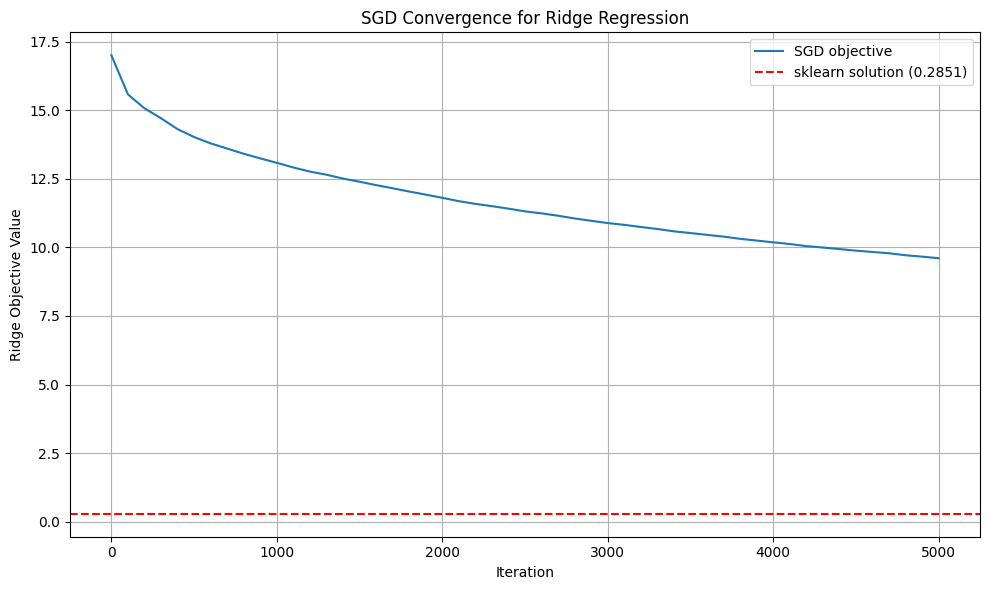

In [6]:
# Compute sklearn objective value for reference
def ridge_objective_full(b, X, y, lam):
    residuals = y - X @ b
    return (1.0 / len(y)) * (np.sum(residuals**2) + lam * np.sum(b[1:]**2))

sklearn_obj = ridge_objective_full(b_sklearn, X_design, y, lam)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(history)) * 100, history, label='SGD objective')
plt.axhline(y=sklearn_obj, color='r', linestyle='--', label=f'sklearn solution ({sklearn_obj:.4f})')
plt.xlabel('Iteration')
plt.ylabel('Ridge Objective Value')
plt.title('SGD Convergence for Ridge Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Compare Coefficients Visually


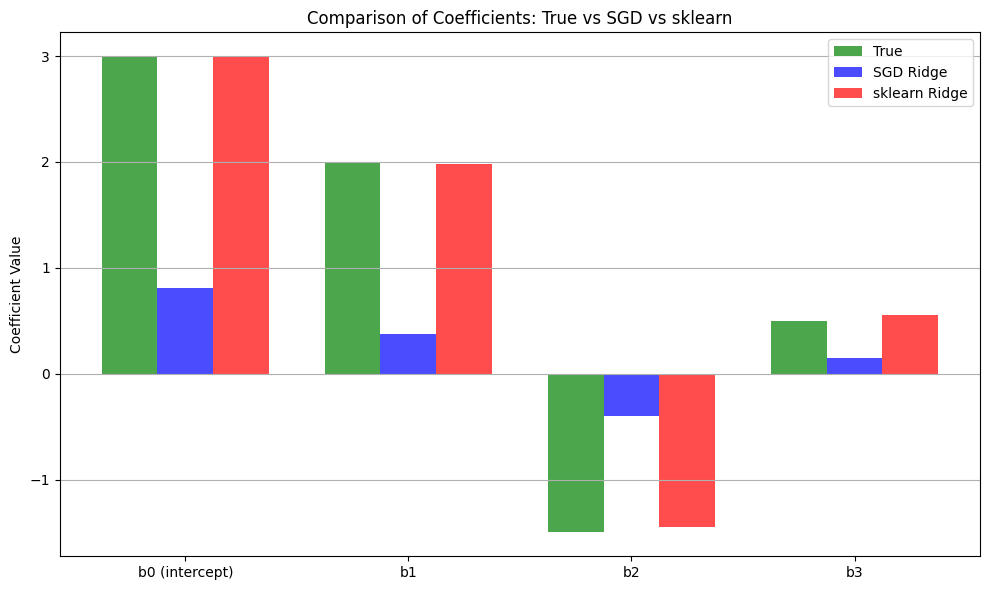

In [7]:
coef_names = ['b0 (intercept)', 'b1', 'b2', 'b3']
x_pos = np.arange(len(coef_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x_pos - width, true_beta, width, label='True', color='green', alpha=0.7)
plt.bar(x_pos, b_sgd, width, label='SGD Ridge', color='blue', alpha=0.7)
plt.bar(x_pos + width, b_sklearn, width, label='sklearn Ridge', color='red', alpha=0.7)
plt.xticks(x_pos, coef_names)
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: True vs SGD vs sklearn')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 7. Observations

**SGD vs sklearn:**
- The SGD Ridge coefficients are close to the sklearn Ridge coefficients, confirming that the implementation is correct.
- The small remaining difference is due to the stochastic nature of SGD (it uses random samples, so the result is noisy).

**SGD vs full Gradient Descent:**
- SGD uses only **one data point** per iteration (cheap per step), whereas full gradient descent computes the gradient over all n data points (expensive per step).
- SGD converges more noisily but is much faster per iteration, making it preferable for large datasets.

**Learning rate:**
- The sqrt decay schedule ($\gamma_m = \gamma / \sqrt{m}$) provides a good balance: fast early progress while still converging.
- A constant learning rate can cause the solution to oscillate around the optimum without settling.

**Ridge shrinkage:**
- Both SGD and sklearn Ridge coefficients are slightly smaller in magnitude than the true coefficients. This is expected: Ridge regression shrinks coefficients toward zero as a trade-off for reduced variance.